In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors

import scanpy as sc

import os


import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols

# Some canonical markers for PBMC cell types that I found
canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

## Load RNA cell Barcodes from RNA-only modality CR analysis

In [2]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm_ln'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])



entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')

# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)



In [3]:
if 'standard_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in entropy_df.columns:
    entropy_df.drop(columns=['entropy_peak_FRIP'], inplace=True)
if 'total_fragments' in entropy_df.columns:
    entropy_df.drop(columns=['total_fragments'], inplace=True)
if 'Nfrag_overlap_standard_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_standard_peak'], inplace=True)
if 'Nfrag_overlap_entropy_peak' in entropy_df.columns:
    entropy_df.drop(columns=['Nfrag_overlap_entropy_peak'], inplace=True)

entropy_df = entropy_df.merge(standard_peak_frip[['frag_overlap_peaks%', 'total_fragments', 'frag_overlap_peaks']].rename(
    columns={'frag_overlap_peaks%': 'standard_peak_FRIP', 'frag_overlap_peaks': 'Nfrag_overlap_standard_peak'}),\
    left_on='atac_bc', right_index=True, how='left')
entropy_df = entropy_df.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%', 'frag_overlap_entropy_peaks']].rename(
    columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP', 'frag_overlap_entropy_peaks': 'Nfrag_overlap_entropy_peak'}),\
    left_on='atac_bc', right_index=True, how='left')


entropy_df['total_fragment_log1p'] = np.log1p(entropy_df['total_fragments'])

## Matching RNA and ATAC barcodes

In [4]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 15)

In [5]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])

In [6]:
entropy_df['identified_by_atac'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

In [7]:
entropy_df['identified_by_atac'].value_counts()

identified_by_atac
none            31080
both             1901
entropy_only      261
cr_only            45
Name: count, dtype: int64

# Plot results

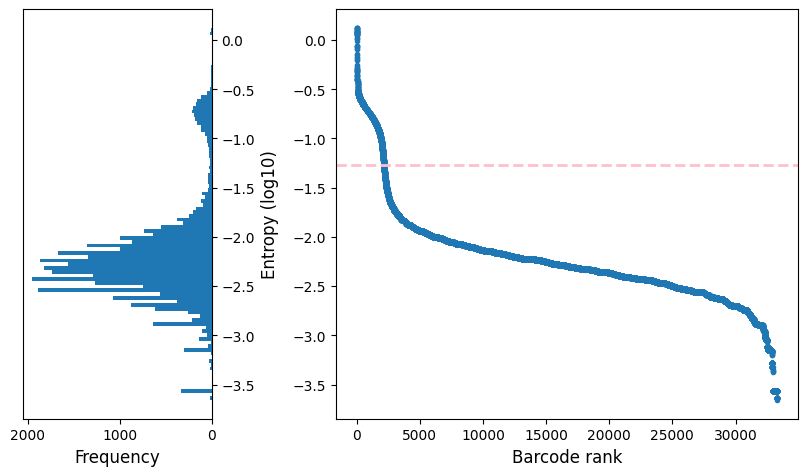

In [8]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:5])
_ = ax0.hist(np.log10(entropy_df['Entropy']), orientation='horizontal', bins=100)
# move y-tick ro the right side 
ax0.yaxis.tick_right()
ax0.yaxis.set_label_position('right')
ax0.invert_xaxis()
ax0.set_ylabel('Entropy (log10)', fontsize=12)
ax0.set_xlabel('Frequency', fontsize=12)


ax1 = fig.add_subplot(gs[0:20,8:])

sorted_log10entropy_list = np.log10(entropy_df['Entropy'].dropna().sort_values(ascending=False).values)
rank_list = np.arange( len(sorted_log10entropy_list) )
entropy_cutoff = entropy_df.loc[entropy_df['atac_pass_entropy'], 'Entropy'].min()
entropy_cutoff_log = np.log10(entropy_cutoff)


ax1.plot( rank_list, sorted_log10entropy_list, 'o', markersize=3)
ax1.set_xlabel('Barcode rank', fontsize=12)
# ax1.set_ylabel('log(Entropy)', fontsize=12)
ax1.axhline(entropy_cutoff_log, color='pink', linestyle='--', label='entropy threshold', lw=2)


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_2563388/909204237.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)
/tmp/ipykernel_2563388/909204237.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)


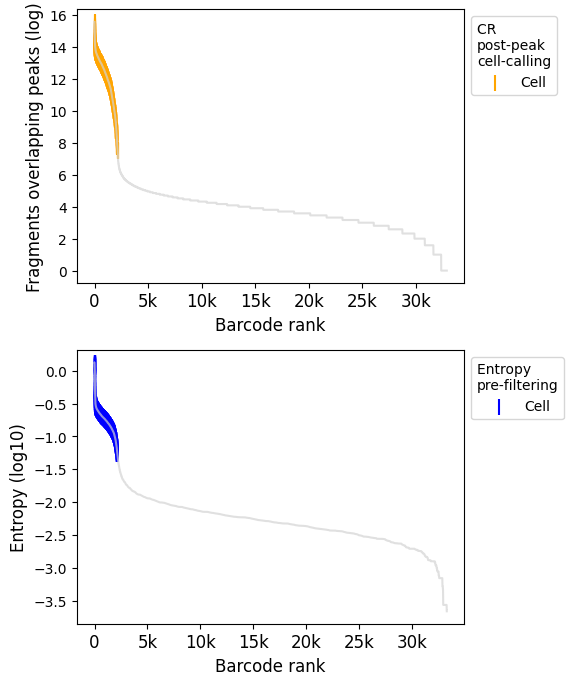

In [9]:


fig = plt.figure(figsize=(5, 12))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:9,:])

ax1 = fig.add_subplot(gs[11:20,:])


# ax0
sorted_frag_overlap_peaks = np.log2(entropy_df['Nfrag_overlap_entropy_peak']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['Nfrag_overlap_entropy_peak'], '-', markersize=7, color='lightgray', alpha=0.7)
ax0.set_xlabel('Barcode rank', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks (log)', fontsize=12)
ax0.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax0.get_xticks()  ], fontsize=12)

barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'Nfrag_overlap_entropy_peak'], color='orange', label='Cell', s=130, alpha=1, marker="|")

ax0.legend(title='CR \npost-peak\ncell-calling', bbox_to_anchor=(1, 1), loc='upper left')


# ax1
sorted_log10entropy_series = np.log10(entropy_df['Entropy'].dropna().sort_values(ascending=False)).to_frame()  # with barcodes as index
rank_list = np.arange( len(sorted_log10entropy_series) )
sorted_log10entropy_series['rank_list'] = rank_list


ax1.plot( rank_list, sorted_log10entropy_series['Entropy'], '-', markersize=7, color='lightgray', alpha=0.7)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)
ax1.set_xticklabels([int(x) if x < 1000 else str(int(x // 1000)) + 'k' for x in  ax1.get_xticks()  ], fontsize=12)

barcodes = entropy_df.loc[entropy_df['atac_pass_entropy']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='blue', label='Cell', s=130, alpha=1, marker="|")
    
ax1.legend(title='Entropy \npre-filtering', bbox_to_anchor=(1, 1), loc='upper left')


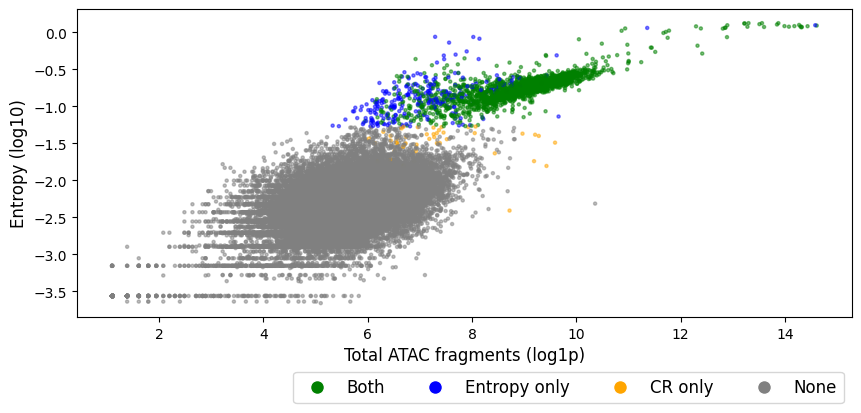

In [10]:


fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( entropy_df['total_fragment_log1p'], np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

# cax_0 = ax.inset_axes([1.1, 0, 0.03, 1], transform=ax.transAxes)
# fig.colorbar(ax.collections, ax=ax, cax=cax_0, label='Fragments% overlapping called peaks')

plt.show()

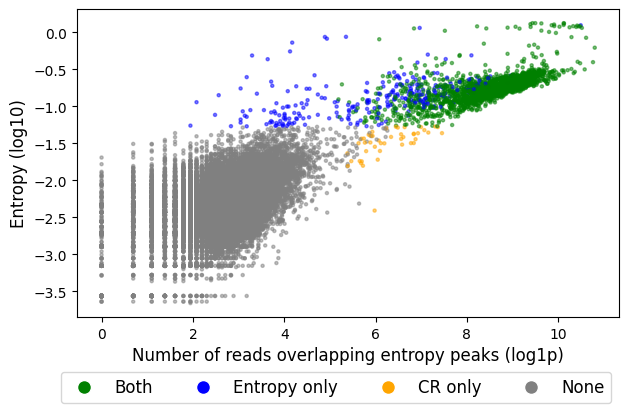

In [11]:


fig, ax = plt.subplots( figsize=(7, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(entropy_df['Nfrag_overlap_entropy_peak']), np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping entropy peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

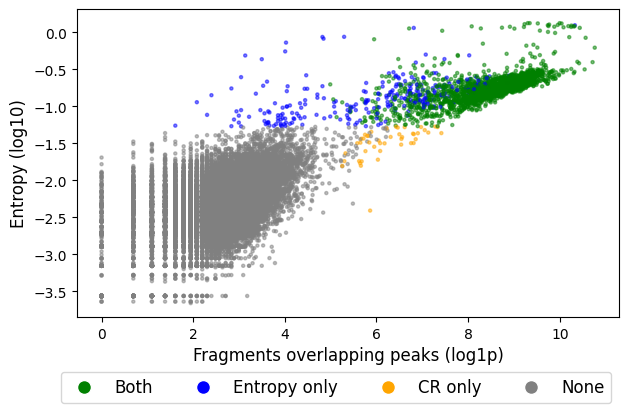

In [12]:
fig, ax = plt.subplots( figsize=(7, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(entropy_df['Nfrag_overlap_standard_peak']), np.log10(entropy_df['Entropy']),  c= entropy_df['identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Number of reads overlapping peaks (log1p)', fontsize=12)
ax.set_xlabel('Fragments overlapping peaks (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

FRIP 	 entropy_only 	 cr_only 

Median 	 62.41 	 54.01 



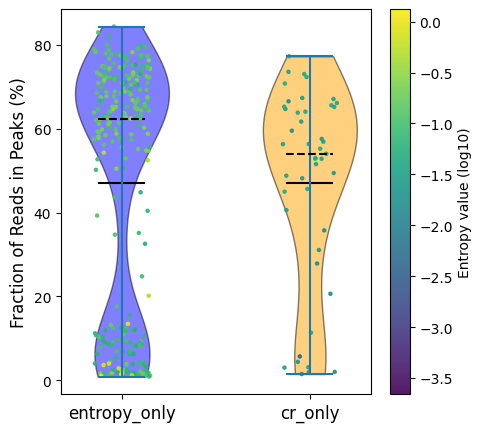

In [13]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))



vp1 = ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, poi_adj, jitter_width, color, color_range):
    # Generate random horizontal jitter
    x_jittered = position + poi_adj+ np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    norm = colors.Normalize(vmin=color_range[0], vmax=color_range[1])
    color_bar = ax.scatter(x_jittered, data_group, c=color, alpha=0.9, s=5, norm=norm) # s controls point size
    return color_bar



for i, group_data in enumerate(standard_peak_data):
    cb = add_jittered_points(ax, group_data, x_positions[i], 0,   color=entropy_values[i],color_range=color_range, jitter_width=0.15)

colorbar = fig.colorbar(cb, ax=ax, label='Entropy value (log10)')


for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.5)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [standard_peak_data[i].median() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_standard_peak[0], median_frip_standard_peak[1]))

FRIP 	 entropy_only 	 cr_only 

Median 	 62.41 	 54.01 

Mean 	 46.93 	 47.03 



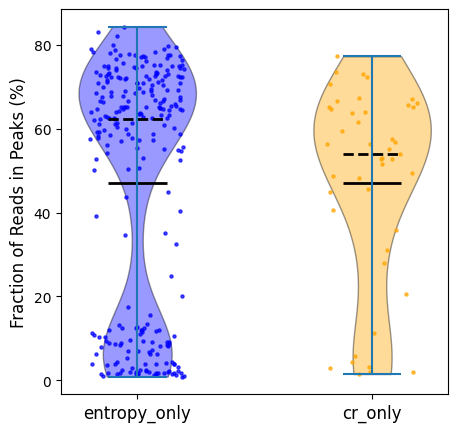

In [22]:
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = [ 'entropy_only', 'cr_only',]
x_positions = range(len(gps))
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(5, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'standard_peak_FRIP'] for c in gps]
entropy_values = [np.log10(entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Entropy']) for c in gps]
color_range = (np.log10(entropy_df['Entropy'].min()), np.log10(entropy_df['Entropy'].max()))


vp1 = ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, showmedians=True,
              showmeans=True)
add_label(vp1, 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.7, s=5) # s controls point size



for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], jitter_width=0.2, color='orange' if gps[i]=='cr_only' else 'blue')



for i, body in enumerate(vp1['bodies']):
    body.set_facecolor('blue' if gps[i]=='entropy_only' else 'orange')
    body.set_edgecolor('black')
    body.set_alpha(0.4)
vp1['cmedians'].set_color('black') 
vp1['cmedians'].set_linestyles('--')
vp1['cmedians'].set_linewidth(2)
vp1['cmeans'].set_linewidth(2)
vp1['cmeans'].set_color('black') 


ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)

median_frip_standard_peak = [standard_peak_data[i].median() for i in range(len(gps))]
mean_frip_standard_peak = [standard_peak_data[i].mean() for i in range(len(gps))]
print("FRIP \t entropy_only \t cr_only \n")
print("Median \t {:.2f} \t {:.2f} \n".format(median_frip_standard_peak[0], median_frip_standard_peak[1]))
print("Mean \t {:.2f} \t {:.2f} \n".format(mean_frip_standard_peak[0], mean_frip_standard_peak[1]))

[Text(0, 0, 'both'),
 Text(1, 0, 'entropy_only'),
 Text(2, 0, 'cr_only'),
 Text(3, 0, 'none')]

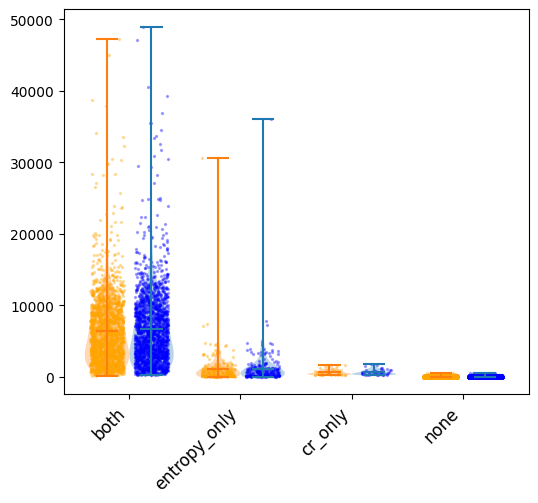

In [15]:
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
gps = ['both', 'entropy_only', 'cr_only', 'none']
x_positions = range(len(gps))
widths=0.4
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(6, 5))

# Violin plots

standard_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_standard_peak'] for c in gps]
entropy_peak_data = [entropy_df.loc[entropy_df['identified_by_atac'] == c, 'Nfrag_overlap_entropy_peak'] for c in gps]

add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks')
add_label(ax.violinplot( standard_peak_data, 
              positions=[x - 0.2 for x in x_positions], widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks')

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i] - 0.2, color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + 0.2 for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels(gps, rotation=45, ha='right', fontsize=12)


/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


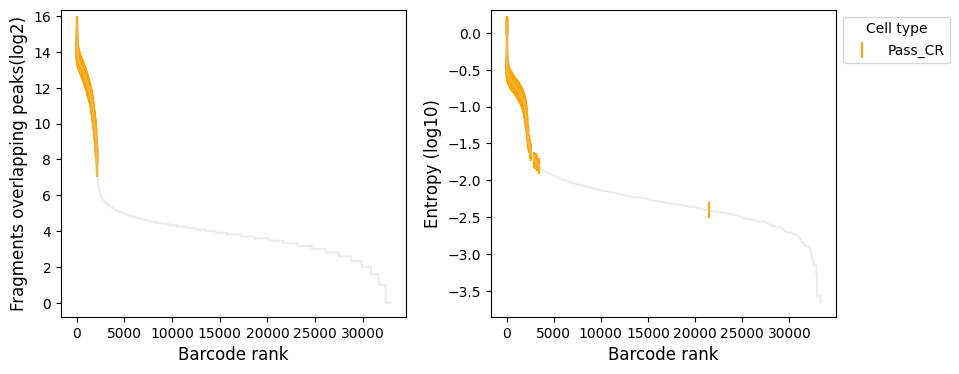

In [16]:


fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(30, 20)

ax0 = fig.add_subplot(gs[0:20,0:9])

sorted_frag_overlap_peaks = np.log2(entropy_df['Nfrag_overlap_entropy_peak']).sort_values(ascending=False).to_frame()  # with barcodes as index
rank_list = np.arange( sorted_frag_overlap_peaks.shape[0] )
sorted_frag_overlap_peaks['rank_list'] = rank_list

ax0.plot( sorted_frag_overlap_peaks['rank_list'], sorted_frag_overlap_peaks['Nfrag_overlap_entropy_peak'], '-', markersize=1, color='lightgray', alpha=0.4)
ax0.set_xlabel('Barcode rank', fontsize=12)
ax0.set_ylabel('Fragments overlapping peaks(log2)', fontsize=12)

barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax0.scatter(sorted_frag_overlap_peaks.loc[barcodes, 'rank_list'], 
            sorted_frag_overlap_peaks.loc[barcodes, 'Nfrag_overlap_entropy_peak'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")



ax1 = fig.add_subplot(gs[0:20,11:])

sorted_log10entropy_series = np.log10(entropy_df['Entropy'].sort_values(ascending=False)).to_frame()  # with barcodes as index 
rank_list = np.arange( sorted_log10entropy_series.shape[0] )
sorted_log10entropy_series['rank_list'] = rank_list



ax1.plot( sorted_log10entropy_series['rank_list'], sorted_log10entropy_series['Entropy'], '-', markersize=1, color='lightgray', alpha=0.4)
ax1.set_xlabel('Barcode rank', fontsize=12)
ax1.set_ylabel('Entropy (log10)', fontsize=12)


barcodes = entropy_df.loc[entropy_df['atac_pass_CR']].index
ax1.scatter(sorted_log10entropy_series.loc[barcodes, 'rank_list'], 
            sorted_log10entropy_series.loc[barcodes, 'Entropy'], color='orange', label='Pass_CR', s=130, alpha=1, marker="|")
    
ax1.legend(title='Cell type', bbox_to_anchor=(1, 1), loc='upper left')

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [np.float64(64.81367815748251), np.float64(46.927474457127445), np.float64(47.02544523013997), np.float64(5.409572938451698)]
median 	 [np.float64(67.05145764038349), np.float64(62.40601503759399), np.float64(54.006410256410255), np.float64(4.3604651162790695)]


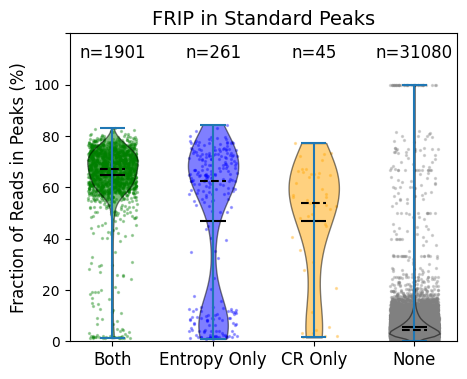

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Standard Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [np.float64(67.28363379380959), np.float64(48.784778218260115), np.float64(48.45908305669495), np.float64(5.762112439972559)]
median 	 [np.float64(69.59223300970874), np.float64(65.21264994547438), np.float64(56.87973997833152), np.float64(4.691720068064154)]


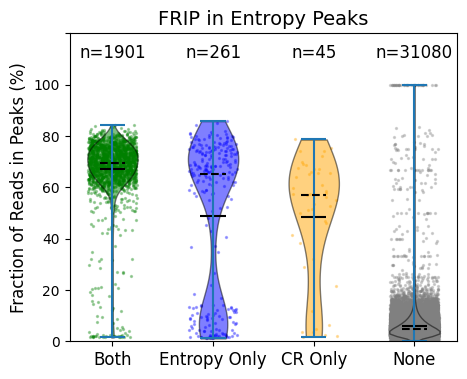

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] for cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

ax.set_title('FRIP in Entropy Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')



----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [np.float64(2.469955636327069), np.float64(1.8573037611326777), np.float64(1.4336378265549854), np.float64(0.3525395015208616)]
median 	 [np.float64(2.369360597208697), np.float64(1.9903912148249816), np.float64(1.2269938650306784), np.float64(0.2053388090349073)]


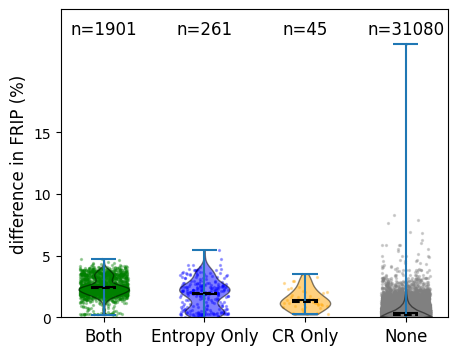

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))

x_positions = range(4)
width = 0.5

colors = ['green', 'blue', 'orange', 'gray']
entropy_vales = [ entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'entropy_peak_FRIP'] - \
    entropy_df.loc[entropy_df['identified_by_atac'] == cat, 'standard_peak_FRIP'] for \
        cat in ['both', 'entropy_only', 'cr_only', 'none'] ]
total_counts = [a.shape[0] for a in entropy_vales]

mean_entropy_values = [np.mean(a) for a in entropy_vales]
median_entropy_values = [np.median(a) for a in entropy_vales]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(entropy_vales):
    add_jittered_points(ax, group_data, x_positions[i], color=colors[i])


v1 = ax.violinplot( entropy_vales, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Both', 'Entropy Only', 'CR Only', 'None'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('difference in FRIP (%)', fontsize=12)
ax.set_ylim(0, 25)
ax.set_yticks(range(0, 20, 5))


for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)
    
print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_entropy_values}')
print(f'median \t {median_entropy_values}')
